# Freight Rate Prediction

This notebook implements a clean, end-to-end machine learning pipeline for the Spotter freight-rate assessment.

The goal is to predict `posted_rate` using a reusable feature engineering pipeline, compare a direct-rate baseline against a domain-optimized rate-per-mile model, and export the final predictions required by the official scoring script.


## 1. Data Ingestion & EDA

This section loads the labeled freight dataset and the validation set, checks core schema assumptions, and summarizes the target distribution and date coverage before any modeling work begins.


In [1]:
from __future__ import annotations

import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

project_root = Path("..").resolve()
data_dir = project_root / "data"
train_path = data_dir / "train-test.csv"
val_path = data_dir / "validation.csv"
dec_path = data_dir / "december-chart-inputs.csv"
template_path = data_dir / "validation-predictions-template.csv"

plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
pd.set_option("display.max_columns", 50)
print(f"Project root: {project_root}")
print(f"Data directory: {data_dir}")


Project root: C:\dev\Freight Rate Prediction
Data directory: C:\dev\Freight Rate Prediction\data


train_test.csv shape:           (48000, 14)
validation.csv shape:           (12000, 13)
december-chart-inputs.csv shape:(31, 7)
validation-predictions-template.csv shape: (12000, 2)

Train date range: 2025-01-01 00:00:00 -> 2025-10-31 00:00:00
Validation date range: 2025-11-01 00:00:00 -> 2025-12-31 00:00:00
December date range: 2025-12-01 00:00:00 -> 2025-12-31 00:00:00

Missing values by column in train_df:
weight          300
market_index    374
dtype: int64

Missing values by column in validation_df:
weight          165
market_index    249
dtype: int64

Target summary (posted_rate):
count    48000.000000
mean      2373.980682
std       1486.493245
min         57.220000
25%       1251.555000
50%       2030.760000
75%       3330.750000
max      25533.000000

Equipment counts in train_df:
{'Dry Van': 27202, 'Reefer': 12045, 'Flatbed': 8753}

Equipment counts in validation_df:
{'Dry Van': 6780, 'Reefer': 3051, 'Flatbed': 2169}


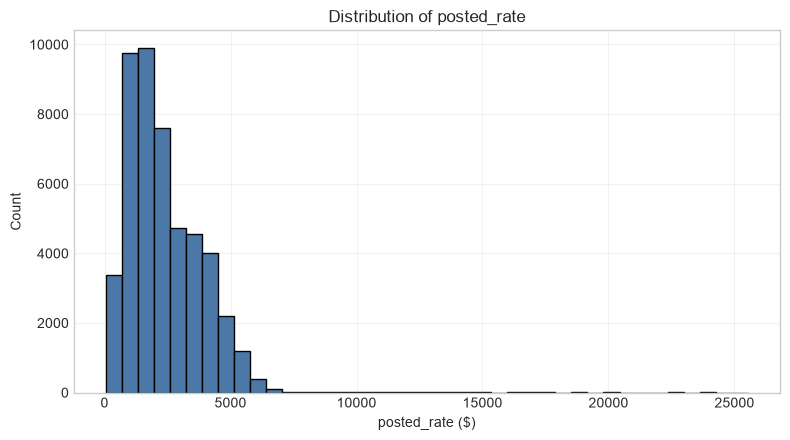

In [2]:
train_df = pd.read_csv(train_path)
val_df = pd.read_csv(val_path)
dec_df = pd.read_csv(dec_path)
template_df = pd.read_csv(template_path)

for df_name, df in [("train", train_df), ("validation", val_df), ("december", dec_df)]:
    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"])

print(f"train_test.csv shape:           {train_df.shape}")
print(f"validation.csv shape:           {val_df.shape}")
print(f"december-chart-inputs.csv shape:{dec_df.shape}")
print(f"validation-predictions-template.csv shape: {template_df.shape}\n")

print("Train date range:", train_df["date"].min(), "->", train_df["date"].max())
print("Validation date range:", val_df["date"].min(), "->", val_df["date"].max())
print("December date range:", dec_df["date"].min(), "->", dec_df["date"].max())

print("\nMissing values by column in train_df:")
print(train_df.isna().sum().loc[lambda s: s > 0])
print("\nMissing values by column in validation_df:")
print(val_df.isna().sum().loc[lambda s: s > 0])

print("\nTarget summary (posted_rate):")
print(train_df["posted_rate"].describe().to_string())

print("\nEquipment counts in train_df:")
print(train_df["equipment"].value_counts().to_dict())

print("\nEquipment counts in validation_df:")
print(val_df["equipment"].value_counts().to_dict())

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(train_df["posted_rate"].dropna(), bins=40, color="#4C78A8", edgecolor="black")
ax.set_title("Distribution of posted_rate")
ax.set_xlabel("posted_rate ($)")
ax.set_ylabel("Count")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## 2. Feature Engineering Pipeline

The next step builds a reusable `engineer_features(df)` function that imputes missing coordinates and market signals, creates corridor and temporal features, and prepares categorical fields for LightGBM without leaking information across the evaluation boundary.



Correlation with posted_rate:
posted_rate     1.000000
distance        0.908519
weight          0.034840
market_index    0.034165
quote_signal   -0.039858
pickup_lat     -0.090873
delivery_lat   -0.091970
pickup_lon     -0.255058
delivery_lon   -0.257086


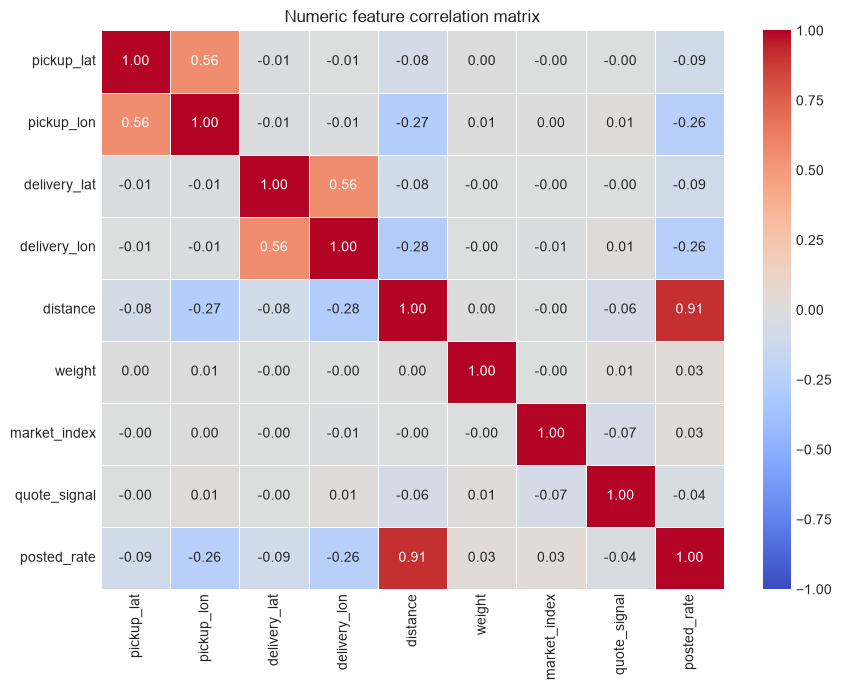


Lane check for Lexington -> Fort Wayne:
Matching rows: 32
 distance equipment  weight  posted_rate
    358.3   Dry Van 22567.0       757.93
    383.2    Reefer 36531.0       933.53
    358.2   Dry Van 31556.0       788.08
    362.1   Dry Van 27842.0       768.22
    357.5   Dry Van 37102.0       807.89


In [3]:
numeric_cols = train_df.select_dtypes(include=[np.number]).columns
corr = train_df[numeric_cols].corr()["posted_rate"].sort_values(ascending=False)
print("\nCorrelation with posted_rate:")
print(corr.to_string())

plt.figure(figsize=(9, 7))
sns = __import__("seaborn")
sns.heatmap(
    train_df[numeric_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
)
plt.title("Numeric feature correlation matrix")
plt.tight_layout()
plt.show()

print("\nLane check for Lexington -> Fort Wayne:")
train_lane = train_df[(train_df["pickup"] == "Lexington") & (train_df["delivery"] == "Fort Wayne")]
print(f"Matching rows: {len(train_lane)}")
if len(train_lane):
    print(train_lane[["distance", "equipment", "weight", "posted_rate"]].head().to_string(index=False))


In [4]:
pickup_coords = train_df.groupby("pickup")[["pickup_lat", "pickup_lon"]].mean().to_dict(orient="index")
delivery_coords = train_df.groupby("delivery")[["delivery_lat", "delivery_lon"]].mean().to_dict(orient="index")
daily_signals = val_df.groupby("date")[["market_index", "quote_signal"]].mean().to_dict(orient="index")

median_weight = train_df["weight"].median()
median_market = train_df["market_index"].median()
median_quote = train_df["quote_signal"].median()

def engineer_features(df_input: pd.DataFrame) -> pd.DataFrame:
    df = df_input.copy()

    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"])

    if "pickup_lat" not in df.columns:
        df["pickup_lat"] = df["pickup"].map(lambda city: pickup_coords.get(city, {}).get("pickup_lat", np.nan))
        df["pickup_lon"] = df["pickup"].map(lambda city: pickup_coords.get(city, {}).get("pickup_lon", np.nan))
        df["delivery_lat"] = df["delivery"].map(lambda city: delivery_coords.get(city, {}).get("delivery_lat", np.nan))
        df["delivery_lon"] = df["delivery"].map(lambda city: delivery_coords.get(city, {}).get("delivery_lon", np.nan))

    if "market_index" not in df.columns:
        df["market_index"] = df["date"].map(lambda d: daily_signals.get(d, {}).get("market_index", median_market))
    if "quote_signal" not in df.columns:
        df["quote_signal"] = df["date"].map(lambda d: daily_signals.get(d, {}).get("quote_signal", median_quote))

    for col, fill_value in {
        "distance": df["distance"].median(),
        "weight": median_weight,
        "market_index": median_market,
        "quote_signal": median_quote,
        "pickup_lat": df["pickup_lat"].median(),
        "pickup_lon": df["pickup_lon"].median(),
        "delivery_lat": df["delivery_lat"].median(),
        "delivery_lon": df["delivery_lon"].median(),
    }.items():
        if col in df.columns:
            df[col] = df[col].fillna(fill_value)

    df["lane"] = df["pickup"].fillna("unknown").astype(str) + "_" + df["delivery"].fillna("unknown").astype(str)
    df["dayofweek"] = df["date"].dt.dayofweek
    df["day"] = df["date"].dt.day
    df["month"] = df["date"].dt.month
    df["dayofyear"] = df["date"].dt.dayofyear
    df["is_weekend"] = df["dayofweek"].isin([5, 6]).astype(int)
    df["dow_sin"] = np.sin(2 * np.pi * df["dayofweek"] / 7.0)
    df["dow_cos"] = np.cos(2 * np.pi * df["dayofweek"] / 7.0)

    distance_safe = df["distance"].replace(0, np.nan).fillna(df["distance"].median()).clip(lower=0)
    weight_safe = df["weight"].replace(0, np.nan).fillna(median_weight).clip(lower=0)

    df["log_distance"] = np.log1p(distance_safe)
    df["log_weight"] = np.log1p(weight_safe)
    df["lat_diff"] = df["delivery_lat"] - df["pickup_lat"]
    df["lon_diff"] = df["delivery_lon"] - df["pickup_lon"]
    df["euclidean_dist"] = np.sqrt(df["lat_diff"] ** 2 + df["lon_diff"] ** 2)

    df["weight_per_mile"] = weight_safe / (distance_safe + 1.0)
    df["market_distance_inter"] = df["market_index"] * distance_safe
    df["quote_market_inter"] = df["quote_signal"] * df["market_index"]
    df["is_reefer"] = (df["equipment"].astype(str).str.lower() == "reefer").astype(int)
    df["is_flatbed"] = (df["equipment"].astype(str).str.lower() == "flatbed").astype(int)

    for cat_col in ["equipment", "pickup", "delivery", "lane"]:
        if cat_col in df.columns:
            df[cat_col] = df[cat_col].astype("category")

    return df

train_engineered = engineer_features(train_df)
val_engineered = engineer_features(val_df)
dec_engineered = engineer_features(dec_df)

feature_cols = [
    c for c in train_engineered.columns
    if c not in ["load_id", "date", "posted_rate", "predicted_rate"]
]
print(f"\nTotal engineered features: {len(feature_cols)}")
print(feature_cols)



Total engineered features: 29
['pickup', 'delivery', 'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'equipment', 'weight', 'market_index', 'quote_signal', 'lane', 'dayofweek', 'day', 'month', 'dayofyear', 'is_weekend', 'dow_sin', 'dow_cos', 'log_distance', 'log_weight', 'lat_diff', 'lon_diff', 'euclidean_dist', 'weight_per_mile', 'market_distance_inter', 'quote_market_inter', 'is_reefer', 'is_flatbed']


## 3. Validation Architecture (Out-of-Time Split)

This section creates a strict temporal holdout to prevent leakage: the model trains on Jan–Aug loads and is evaluated on Sep–Oct loads, which matches the real deployment setting more closely than random splitting.


In [5]:
split_date = pd.Timestamp("2025-09-01")
train_mask = train_engineered["date"] < split_date
holdout_mask = train_engineered["date"] >= split_date

X_tr = train_engineered.loc[train_mask, feature_cols]
y_tr = train_engineered.loc[train_mask, "posted_rate"]
X_te = train_engineered.loc[holdout_mask, feature_cols]
y_te = train_engineered.loc[holdout_mask, "posted_rate"]

print(f"\nTrain rows before {split_date.date()}: {len(X_tr):,}")
print(f"Holdout rows from {split_date.date()} onward: {len(X_te):,}")

baseline_model = LGBMRegressor(
    objective="mae",
    n_estimators=1000,
    learning_rate=0.03,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
)
baseline_model.fit(X_tr, y_tr)

baseline_pred = baseline_model.predict(X_te)
baseline_mae = mean_absolute_error(y_te, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_te, baseline_pred))
baseline_r2 = r2_score(y_te, baseline_pred)

print("\nBaseline model metrics (direct posted_rate prediction):")
print(f"MAE:  ${baseline_mae:.2f}")
print(f"RMSE: ${baseline_rmse:.2f}")
print(f"R²:   {baseline_r2:.4f}")



Train rows before 2025-09-01: 38,477
Holdout rows from 2025-09-01 onward: 9,523
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003302 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7467
[LightGBM] [Info] Number of data points in the train set: 38477, number of used features: 29
[LightGBM] [Info] Start training from score 2026.040039

Baseline model metrics (direct posted_rate prediction):
MAE:  $125.16
RMSE: $639.02
R²:   0.8247


## 4. Model Comparison & Evaluation (Holdout Metrics)

Two LightGBM models are compared on the same September–October holdout window: a direct `posted_rate` model and a domain-optimized model that predicts rate per mile and converts back to the dollar rate using the observed distance.


In [6]:
train_v2 = engineer_features(train_df).copy()
val_v2 = engineer_features(val_df).copy()

train_v2["rpm"] = train_v2["posted_rate"] / train_v2["distance"].replace(0, np.nan).fillna(train_v2["distance"].median())

feature_cols_v2 = [
    c for c in train_v2.columns
    if c not in ["load_id", "date", "posted_rate", "predicted_rate", "rpm"]
]

X_tr_v2 = train_v2.loc[train_mask, feature_cols_v2]
y_tr_rpm = train_v2.loc[train_mask, "rpm"]

X_te_v2 = train_v2.loc[holdout_mask, feature_cols_v2]
y_te_rate = train_v2.loc[holdout_mask, "posted_rate"]
dist_te = train_v2.loc[holdout_mask, "distance"]

rpm_model = LGBMRegressor(
    objective="mae",
    n_estimators=1200,
    learning_rate=0.03,
    num_leaves=45,
    min_child_samples=25,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
)
rpm_model.fit(X_tr_v2, y_tr_rpm)

pred_rpm = rpm_model.predict(X_te_v2)
pred_rate_v2 = pred_rpm * dist_te
pred_rate_v2 = np.clip(pred_rate_v2, a_min=50.0, a_max=None)

rpm_mae = mean_absolute_error(y_te_rate, pred_rate_v2)
rpm_rmse = np.sqrt(mean_squared_error(y_te_rate, pred_rate_v2))
rpm_r2 = r2_score(y_te_rate, pred_rate_v2)

comparison_df = pd.DataFrame({
    "Model": ["Baseline (Direct Rate)", "Domain-Optimized (RPM)"],
    "Holdout MAE": [f"${baseline_mae:.2f}", f"${rpm_mae:.2f}"],
    "Holdout RMSE": [f"${baseline_rmse:.2f}", f"${rpm_rmse:.2f}"],
    "R² Score": [f"{baseline_r2:.4f}", f"{rpm_r2:.4f}"],
})
print("\nComparison of holdout performance:")
print(comparison_df.to_string(index=False))
improvement = (baseline_mae - rpm_mae) / baseline_mae * 100.0
print(f"\nMAE improvement from baseline to rpm model: ${baseline_mae - rpm_mae:.2f} ({improvement:.2f}%)")


[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004013 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7467
[LightGBM] [Info] Number of data points in the train set: 38477, number of used features: 29
[LightGBM] [Info] Start training from score 2.141151

Comparison of holdout performance:
                 Model Holdout MAE Holdout RMSE R² Score
Baseline (Direct Rate)     $125.16      $639.02   0.8247
Domain-Optimized (RPM)     $112.49      $635.22   0.8267

MAE improvement from baseline to rpm model: $12.67 (10.13%)


## 5. Winning Model Retraining & Export

The best-performing rate-per-mile model is re-trained on the full labeled dataset, then used to create the final validation predictions and update the December forecasting file in place while preserving the exact contract expected by the scorer.


In [7]:
train_final = engineer_features(train_df).copy()
val_final = engineer_features(val_df).copy()
dec_final = engineer_features(dec_df).copy()

train_final["rpm"] = train_final["posted_rate"] / train_final["distance"].replace(0, np.nan).fillna(train_final["distance"].median())
feature_cols_final = [
    c for c in train_final.columns
    if c not in ["load_id", "date", "posted_rate", "predicted_rate", "rpm"]
]

X_all = train_final[feature_cols_final]
y_all_rpm = train_final["rpm"]

final_rpm_model = LGBMRegressor(
    objective="mae",
    n_estimators=1200,
    learning_rate=0.03,
    num_leaves=45,
    min_child_samples=25,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
)
final_rpm_model.fit(X_all, y_all_rpm)

val_pred_rpm = final_rpm_model.predict(val_final[feature_cols_final])
final_val_rates = np.clip(val_pred_rpm * val_final["distance"], a_min=50.0, a_max=None)

submission_df = pd.DataFrame({
    "load_id": template_df["load_id"],
    "predicted_rate": final_val_rates,
})

submission_df.to_csv(project_root / "validation_predictions.csv", index=False)
submission_df.to_csv(data_dir / "validation_predictions.csv", index=False)
print(f"Saved validation_predictions.csv to {project_root} and {data_dir} with {len(submission_df):,} rows.")

pred_dec_rpm = final_rpm_model.predict(dec_final[feature_cols_final])
dec_output = dec_final[["pickup", "delivery", "distance", "equipment", "weight", "date"]].copy()
dec_output["predicted_rate"] = np.clip(pred_dec_rpm * dec_output["distance"], a_min=50.0, a_max=None)
dec_output = dec_output[["pickup", "delivery", "distance", "equipment", "weight", "date", "predicted_rate"]].sort_values("date").reset_index(drop=True)
dec_output.to_csv(data_dir / "december-chart-inputs.csv", index=False)

print(f"Updated {data_dir / 'december-chart-inputs.csv'} with predictions for {len(dec_output)} rows.")
print(f"NaN predicted_rate values: {dec_output['predicted_rate'].isna().sum()}")
print(f"Columns in December output: {list(dec_output.columns)}")

score_cmd = [
    sys.executable,
    str(project_root / "score.py"),
    "--predictions",
    str(project_root / "validation_predictions.csv"),
    "--december-predictions",
    str(data_dir / "december-chart-inputs.csv"),
]
score_result = subprocess.run(score_cmd, capture_output=True, text=True, cwd=str(project_root))
print("\n--- score.py validation ---")
print(score_result.stdout.strip())
if score_result.returncode != 0:
    raise RuntimeError(score_result.stderr.strip() or "score.py failed")


[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004130 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7531
[LightGBM] [Info] Number of data points in the train set: 48000, number of used features: 29
[LightGBM] [Info] Start training from score 2.145348
Saved validation_predictions.csv to C:\dev\Freight Rate Prediction and C:\dev\Freight Rate Prediction\data with 12,000 rows.
Updated C:\dev\Freight Rate Prediction\data\december-chart-inputs.csv with predictions for 31 rows.
NaN predicted_rate values: 0
Columns in December output: ['pickup', 'delivery', 'distance', 'equipment', 'weight', 'date', 'predicted_rate']

--- score.py validation ---
Validated 12,000 final predictio